# Agricultural Parcels — Statistics & Evolution

**Data sources**
- `reparer/agr/1831.geojson` and `reparer/agr/1888.geojson` — original cadastre snapshots
- `differences/agr_{agr_year}_sans_bat_{build_year}.geojson` — agr parcels minus buildings of a given year → approximation of the agricultural footprint at `build_year`

**Timeline reconstructed:** 1831 → 1873 → 1875 → 1888 → 1889 → 1894 → 1925 → 1926 → 1928 → 1934 → 1945

In [89]:
import json
import math
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from pathlib import Path
from shapely.geometry import shape
import shapely as _shapely
import warnings
warnings.filterwarnings('ignore')

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Load all datasets

In [90]:
BASE = Path('.')

ORIGINALS = {
    1831: BASE / 'reparer/agr/1831.geojson',
    1888: BASE / 'reparer/agr/1888_complete.geojson',
}

DIFFS = {
    1873: BASE / 'differences/agr_1831_sans_bat_1873.geojson',
    1875: BASE / 'differences/agr_1831_sans_bat_1875.geojson',
    1889: BASE / 'differences/agr_1888_sans_bat_1889.geojson',
    1894: BASE / 'differences/agr_1888_sans_bat_1894.geojson',
    1925: BASE / 'differences/agr_1888_sans_bat_1925.geojson',
    1926: BASE / 'differences/agr_1888_sans_bat_1926.geojson',
    1928: BASE / 'differences/agr_1888_sans_bat_1928.geojson',
    1934: BASE / 'differences/agr_1888_sans_bat_1934.geojson',
    1945: BASE / 'differences/agr_1888_sans_bat_1945.geojson',
}

def _detect_crs(data):
    """Read the CRS embedded in a GeoJSON FeatureCollection (non-standard but common)."""
    try:
        name = data['crs']['properties']['name']
        if '2056' in name:
            return 'EPSG:2056'
        if 'CRS84' in name or '4326' in name:
            return 'EPSG:4326'
    except (KeyError, TypeError):
        pass
    return 'EPSG:4326'  # GeoJSON default

def load_gdf(path, year, source_type):
    # fiona silently drops JSON array fields (OGR type 5), so we parse manually
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    file_crs = _detect_crs(data)

    rows, geometries = [], []
    for feat in data['features']:
        rows.append(feat['properties'].copy())
        geometries.append(_shapely.from_geojson(json.dumps(feat['geometry'])))

    df = pd.DataFrame(rows)
    gdf = gpd.GeoDataFrame(df, geometry=geometries, crs=file_crs)
    gdf['year'] = year
    gdf['source'] = source_type

    # Compute area in LV95 (m²), then store everything in WGS84 for consistency
    if file_crs == 'EPSG:2056':
        gdf['area_m2'] = gdf.geometry.area      # already metric
        gdf = gdf.to_crs(epsg=4326)
    else:
        gdf_proj = gdf.to_crs(epsg=2056)
        gdf['area_m2'] = gdf_proj.geometry.area

    # 'use' is a list in all files — take first element
    if 'use' in gdf.columns:
        gdf['use_type'] = gdf['use'].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) > 0
            else (x if isinstance(x, str) else 'unknown')
        )
    elif 'subclass' in gdf.columns:
        _sub_map = {
            'grassland': 'grass', 'meadow': 'grass',
            'vineyard': 'vineyard', 'vigne': 'vineyard',
            'forest': 'forest', 'bois': 'forest',
            'farmland': 'farmland', 'arable': 'farmland',
            'allotment': 'allotments', 'garden': 'allotments',
            'animal': 'animal_keeping', 'stable': 'animal_keeping',
            'water': 'basin', 'basin': 'basin',
        }
        def _map_sub(s):
            s = str(s).lower()
            for k, v in _sub_map.items():
                if k in s:
                    return v
            return 'unknown'
        gdf['use_type'] = gdf['subclass'].apply(_map_sub)
    else:
        gdf['use_type'] = 'unknown'

    # use_fr may be a list (1831) or a string (1888/diffs) — normalise to string
    if 'use_fr' in gdf.columns:
        gdf['use_fr'] = gdf['use_fr'].apply(
            lambda x: ', '.join(x) if isinstance(x, list) else str(x) if x else ''
        )

    return gdf

frames = []
for yr, path in ORIGINALS.items():
    frames.append(load_gdf(path, yr, 'original'))
for yr, path in DIFFS.items():
    frames.append(load_gdf(path, yr, 'approximation'))

all_gdf = pd.concat(frames, ignore_index=True)
print(f"Total features loaded: {len(all_gdf):,}")
print(f"Years covered: {sorted(all_gdf['year'].unique())}")
print(f"\nUse types found:")
print(all_gdf['use_type'].value_counts())

Total features loaded: 168,577
Years covered: [np.int64(1831), np.int64(1873), np.int64(1875), np.int64(1888), np.int64(1889), np.int64(1894), np.int64(1925), np.int64(1926), np.int64(1928), np.int64(1934), np.int64(1945)]

Use types found:
use_type
unknown             105253
grass                13030
allotments           12429
farmland             10961
animal_keeping       10477
forest                7595
vineyard              7574
greenhouse_horti       995
basin                  176
plant_nursery           87
Name: count, dtype: int64


In [91]:
# Load today's data (year 2025) from two sources:
#   - landuse_final.geojson  → grass and forest (authoritative agricultural declaration data)
#   - landuse_lausanne.geojson → all other agricultural uses (OSM-derived)
# Both files are in EPSG:2056 (Swiss LV95); area is computed there, then reprojected to WGS84
# to match the CRS of all_gdf before concatenation.

TODAY_YEAR = 2025

LAUSANNE_TYPE_MAP = {
    'allotments':              'allotments',
    'farmland':                'farmland',
    'vineyard':                'vineyard',
    'animal_keeping':          'animal_keeping',
    'farmyard':                'animal_keeping',
    'basin':                   'basin',
    'reservoir':               'basin',
    'orchard':                 'allotments',
    'greenhouse_horticulture': 'greenhouse_horticulture',
    'plant_nursery':           'plant_nursery',
}

def load_today():
    parts = []

    # 1. grass + forest from landuse_final.geojson
    with open(BASE / 'today/landuse_final.geojson', 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows, geoms = [], []
    for feat in data['features']:
        use = feat['properties'].get('UTILISATIO', '')
        if use in ('grass', 'forest'):
            rows.append({'use_type': use, 'use_fr': use, 'year': TODAY_YEAR, 'source': 'today'})
            geoms.append(_shapely.from_geojson(json.dumps(feat['geometry'])))
    gdf_f = gpd.GeoDataFrame(rows, geometry=geoms, crs='EPSG:2056')
    gdf_f['area_m2'] = gdf_f.geometry.area
    gdf_f = gdf_f.to_crs(epsg=4326)
    parts.append(gdf_f)
    print(f"  landuse_final  : {len(gdf_f):,} features (grass/forest)")

    # 2. other agricultural uses from landuse_lausanne.geojson
    with open(BASE / 'today/landuse_lausanne.geojson', 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows, geoms = [], []
    for feat in data['features']:
        raw_type = feat['properties'].get('type', '')
        use = LAUSANNE_TYPE_MAP.get(raw_type)
        if use is None:
            continue
        rows.append({'use_type': use, 'use_fr': feat['properties'].get('name', '') or use,
                     'year': TODAY_YEAR, 'source': 'today'})
        geoms.append(_shapely.from_geojson(json.dumps(feat['geometry'])))
    gdf_l = gpd.GeoDataFrame(rows, geometry=geoms, crs='EPSG:2056')
    gdf_l['area_m2'] = gdf_l.geometry.area
    gdf_l = gdf_l.to_crs(epsg=4326)
    parts.append(gdf_l)
    print(f"  landuse_lausanne: {len(gdf_l):,} features (other agr. uses)")

    return pd.concat(parts, ignore_index=True)

print(f"Loading today's data ({TODAY_YEAR})…")
today_gdf = load_today()
all_gdf = pd.concat([all_gdf, today_gdf], ignore_index=True)

print(f"\nTotal features after adding 2025: {len(all_gdf):,}")
print(f"Years covered: {sorted(all_gdf['year'].unique())}")
print(f"\nUse types in 2025 data:")
print(today_gdf['use_type'].value_counts())
print(f"Total 2025 area: {today_gdf['area_m2'].sum()/1e4:.1f} ha")

Loading today's data (2025)…
  landuse_final  : 680 features (grass/forest)
  landuse_lausanne: 78 features (other agr. uses)

Total features after adding 2025: 169,335
Years covered: [np.int64(1831), np.int64(1873), np.int64(1875), np.int64(1888), np.int64(1889), np.int64(1894), np.int64(1925), np.int64(1926), np.int64(1928), np.int64(1934), np.int64(1945), np.int64(2025)]

Use types in 2025 data:
use_type
grass             555
forest            125
farmland           31
allotments         23
animal_keeping     21
plant_nursery       1
vineyard            1
basin               1
Name: count, dtype: int64
Total 2025 area: 5708.5 ha


## 2. Summary table — total area and parcel count per year

In [92]:
summary = (
    all_gdf.groupby(['year', 'source'])
    .agg(n_parcels=('area_m2', 'count'), total_area_ha=('area_m2', lambda x: x.sum() / 1e4))
    .reset_index()
    .sort_values('year')
)
summary['total_area_ha'] = summary['total_area_ha'].round(2)
display(summary.to_string(index=False))

' year        source  n_parcels  total_area_ha\n 1831      original       5650        3913.25\n 1873 approximation       5597        3890.19\n 1875 approximation       5587        3894.51\n 1888      original      20169        4056.14\n 1889 approximation      19092        4025.08\n 1894 approximation      19064        4019.52\n 1925 approximation      19606        4034.86\n 1926 approximation      18774        3993.74\n 1928 approximation      18458        3961.35\n 1934 approximation      18229        3932.12\n 1945 approximation      18351        3949.65\n 2025         today        758        5708.51'

## 3. Use-type colour palette

In [93]:
USE_COLORS = {
    'allotments':              '#6abf69',  # medium green
    'grass':                   '#b5d46e',  # yellow-green
    'farmland':                '#e6c87a',  # warm yellow
    'vineyard':                '#9b59b6',  # purple
    'animal_keeping':          '#e67e22',  # orange
    'forest':                  '#27ae60',  # dark green
    'basin':                   '#3498db',  # blue
    'greenhouse_horticulture': '#1abc9c',  # teal
    'plant_nursery':           '#e91e63',  # rose/pink
}

USE_LABELS = {
    'allotments':              'Jardins / Allotments',
    'grass':                   'Prés / Grass',
    'farmland':                'Terres arables / Farmland',
    'vineyard':                'Vignes / Vineyard',
    'animal_keeping':          'Hangars / Animal keeping',
    'forest':                  'Forêt / Forest',
    'basin':                   'Bassins / Basin',
    'greenhouse_horticulture': 'Serres / Greenhouse',
    'plant_nursery':           'Pépinières / Plant nursery',
}

# Remove 'unknown' from data entirely so it never appears in any plot or table
all_gdf = all_gdf[all_gdf['use_type'] != 'unknown'].copy()

all_types = sorted(all_gdf['use_type'].unique())
print("Use types in dataset:", all_types)
for t in all_types:
    if t not in USE_COLORS:
        print(f"  WARNING: no colour defined for '{t}' — add it to USE_COLORS above")
        USE_COLORS[t] = '#bdc3c7'
        USE_LABELS[t] = t

Use types in dataset: ['allotments', 'animal_keeping', 'basin', 'farmland', 'forest', 'grass', 'greenhouse_horti', 'plant_nursery', 'vineyard']


## 4. Area by use type — pivot over time

In [94]:
area_pivot = (
    all_gdf.groupby(['year', 'use_type'])['area_m2']
    .sum()
    .unstack(fill_value=0)
    / 1e4  # convert to hectares
)
area_pivot = area_pivot.sort_index()
print("Area (ha) per use type and year:")
display(area_pivot.round(2))

Area (ha) per use type and year:


use_type,allotments,animal_keeping,basin,farmland,forest,grass,greenhouse_horti,plant_nursery,vineyard
year,,,,,,,,,
1831,60.13,10.03,0.07,978.09,1560.17,1066.78,0.27,5.31,232.41
1873,54.92,8.71,0.06,974.32,1559.38,1058.41,0.23,5.24,228.92
1875,55.83,9.04,0.06,974.85,1559.61,1060.02,0.24,5.25,229.63
1888,104.61,66.65,0.97,774.84,704.97,857.15,1.11,0.00,168.36
1889,97.20,63.90,0.91,773.57,704.34,851.06,1.01,0.00,166.66
1894,96.56,63.22,0.93,772.69,704.24,849.87,1.01,0.00,166.28
1925,101.38,66.37,0.97,773.12,704.94,850.79,1.09,0.00,164.53
1926,94.00,62.62,0.90,767.77,703.35,843.69,0.96,0.00,159.76
1928,88.79,61.61,0.86,764.54,703.16,835.78,0.92,0.00,153.61


## 5. Stacked area chart — agricultural land use over time

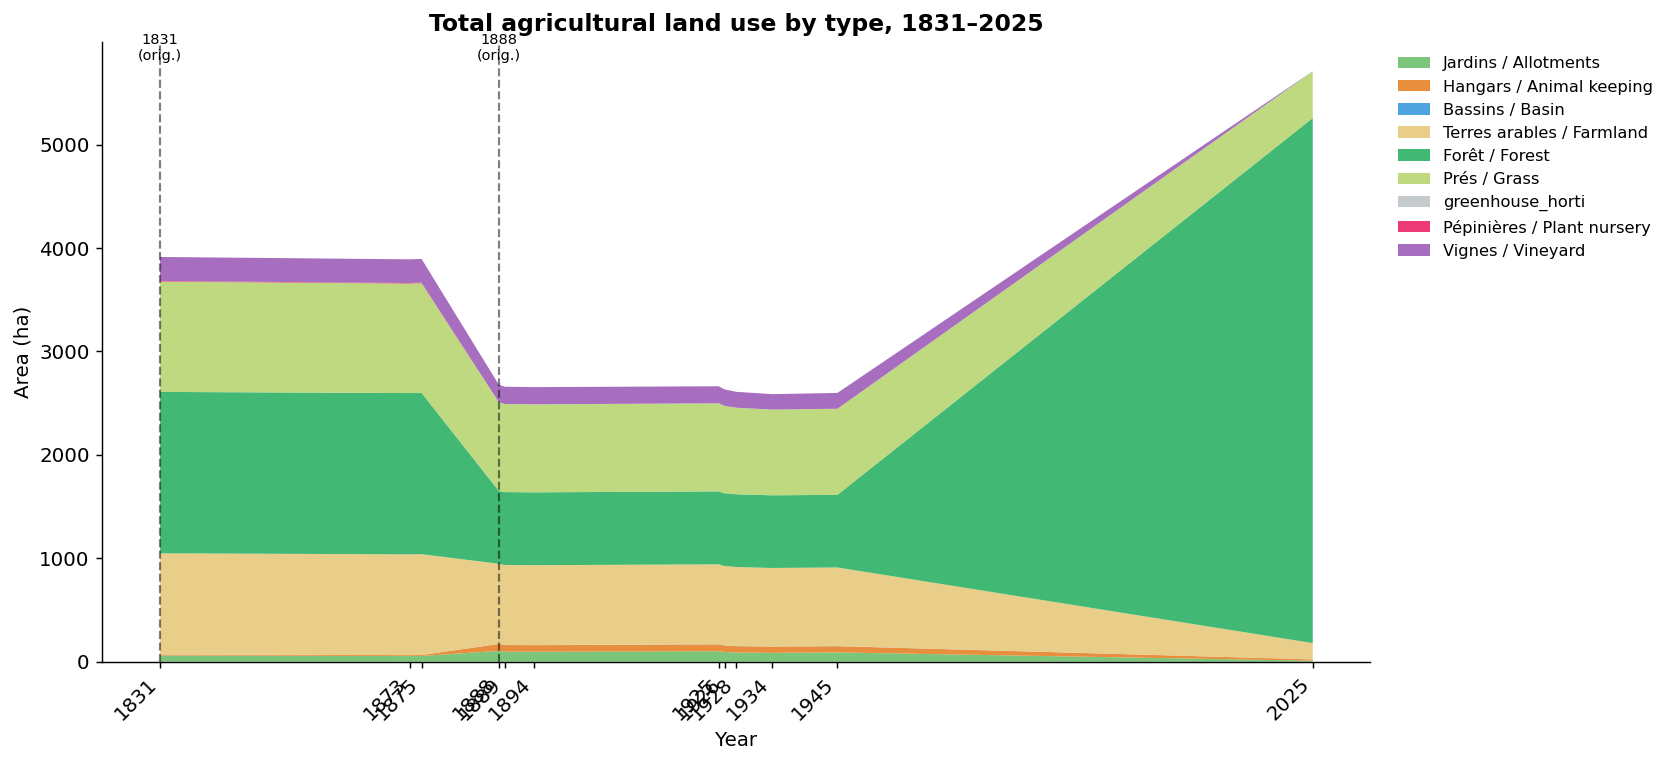

In [95]:
years = area_pivot.index.tolist()
cols = [c for c in area_pivot.columns if c in USE_COLORS]
colors = [USE_COLORS[c] for c in cols]
labels = [USE_LABELS.get(c, c) for c in cols]

fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(years, [area_pivot[c] for c in cols],
             labels=labels, colors=colors, alpha=0.88)

ax.set_xlabel('Year')
ax.set_ylabel('Area (ha)')
ax.set_title('Total agricultural land use by type, 1831–2025', fontsize=13, fontweight='bold')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')

orig_years = list(ORIGINALS.keys())
for yr in orig_years:
    ax.axvline(yr, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='_nolegend_')
    ax.text(yr, ax.get_ylim()[1] * 0.97, f'{yr}\n(orig.)', ha='center', fontsize=8, color='black')

handles, lbls = ax.get_legend_handles_labels()
ax.legend(handles, lbls, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '01_stacked_area_over_time.png', bbox_inches='tight')
plt.show()

## 6. Line chart — individual use types over time

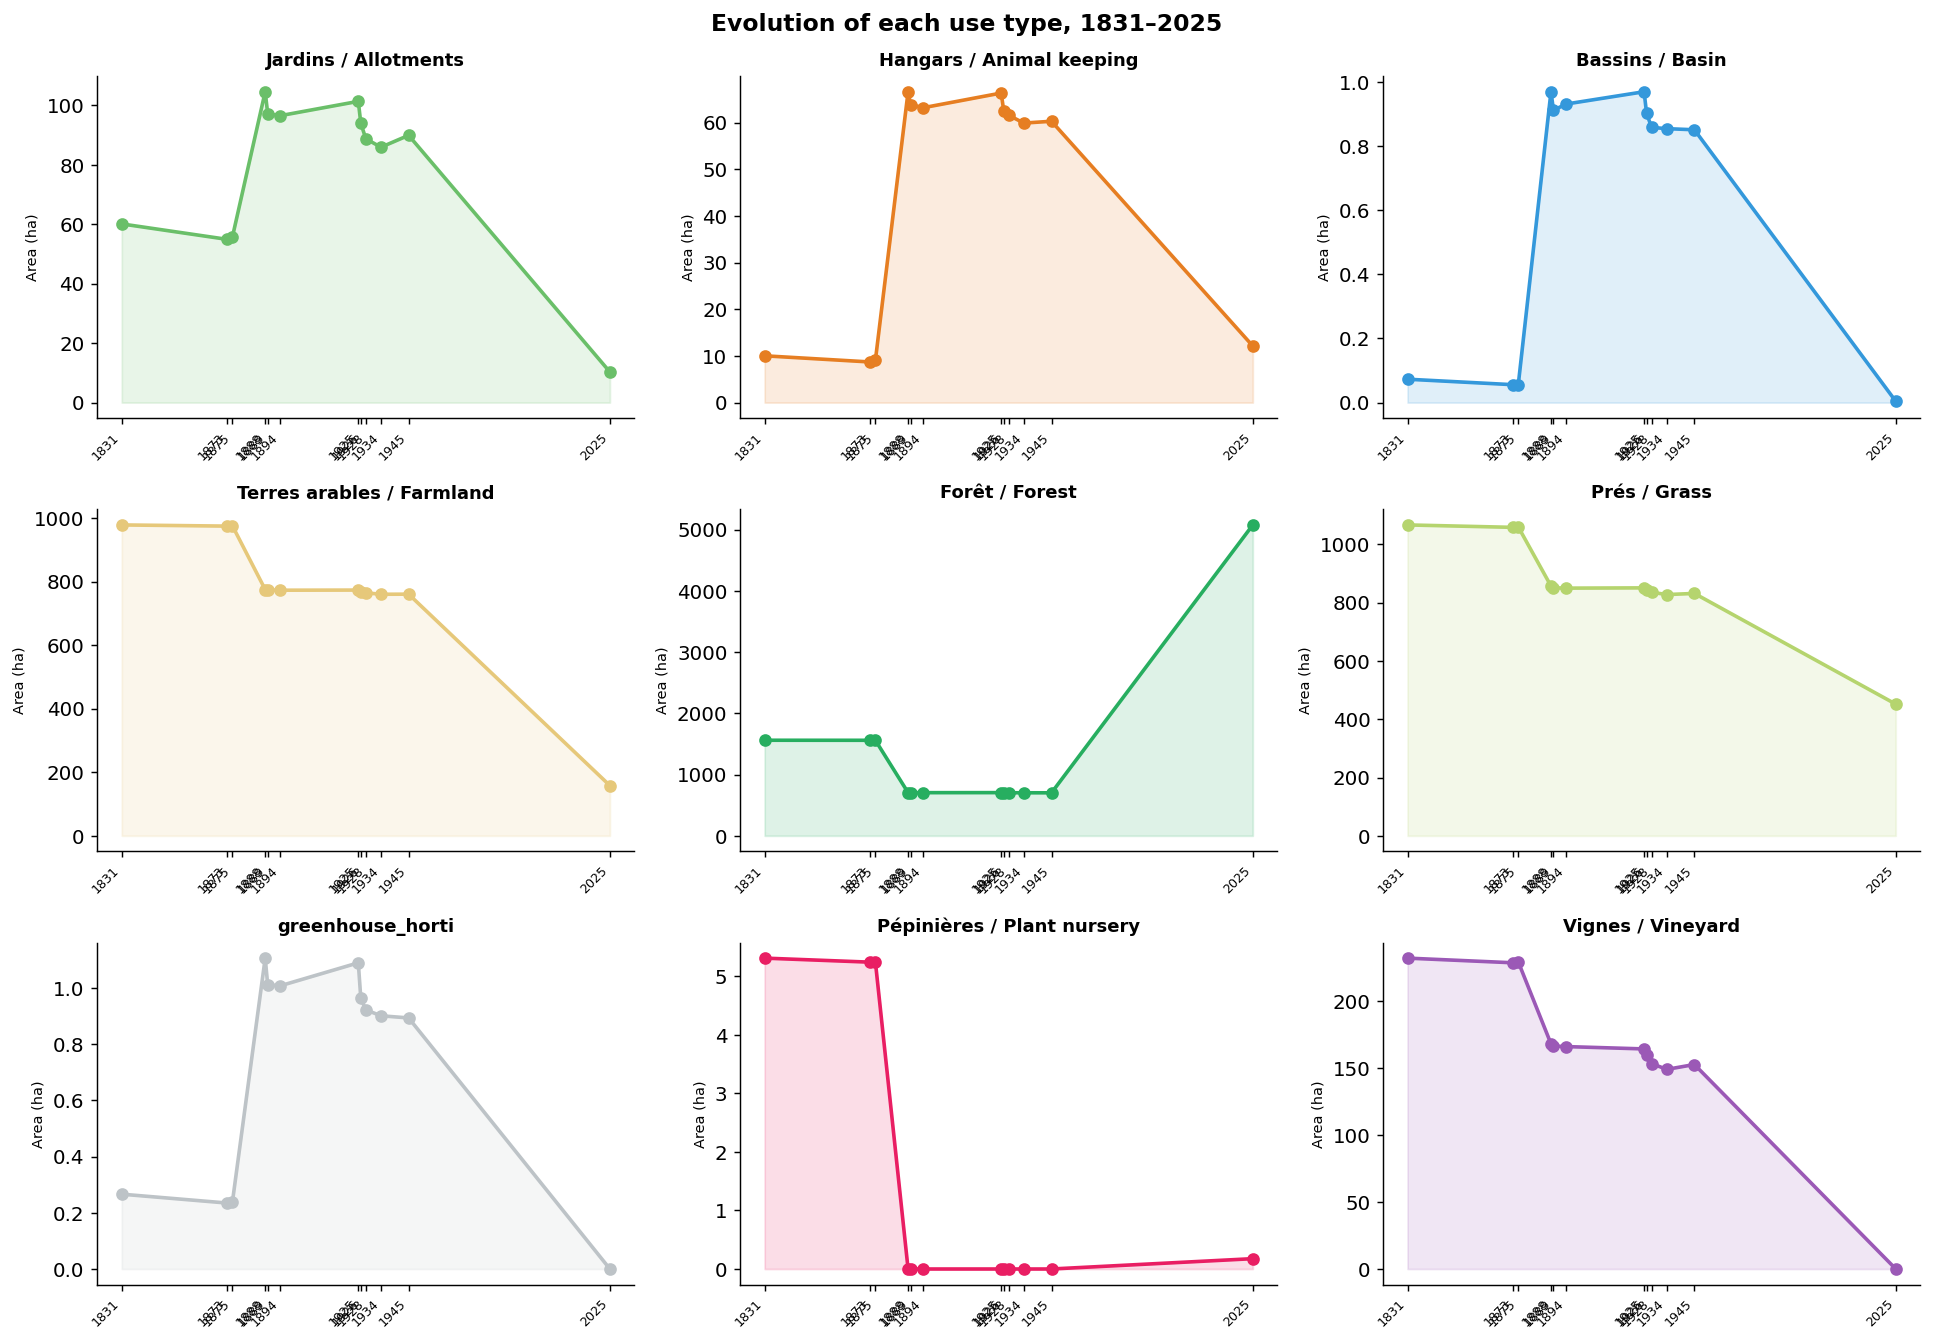

In [96]:
ncols = 3
nrows = math.ceil(len(cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(years, area_pivot[col], marker='o', color=USE_COLORS[col], linewidth=2)
    ax.set_title(USE_LABELS.get(col, col), fontweight='bold', fontsize=10)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Area (ha)', fontsize=8)
    ax.fill_between(years, area_pivot[col], alpha=0.15, color=USE_COLORS[col])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Evolution of each use type, 1831–2025', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02_area_evolution_by_use_type.png', bbox_inches='tight')
plt.show()

## 7. Relative composition — 100% stacked bar

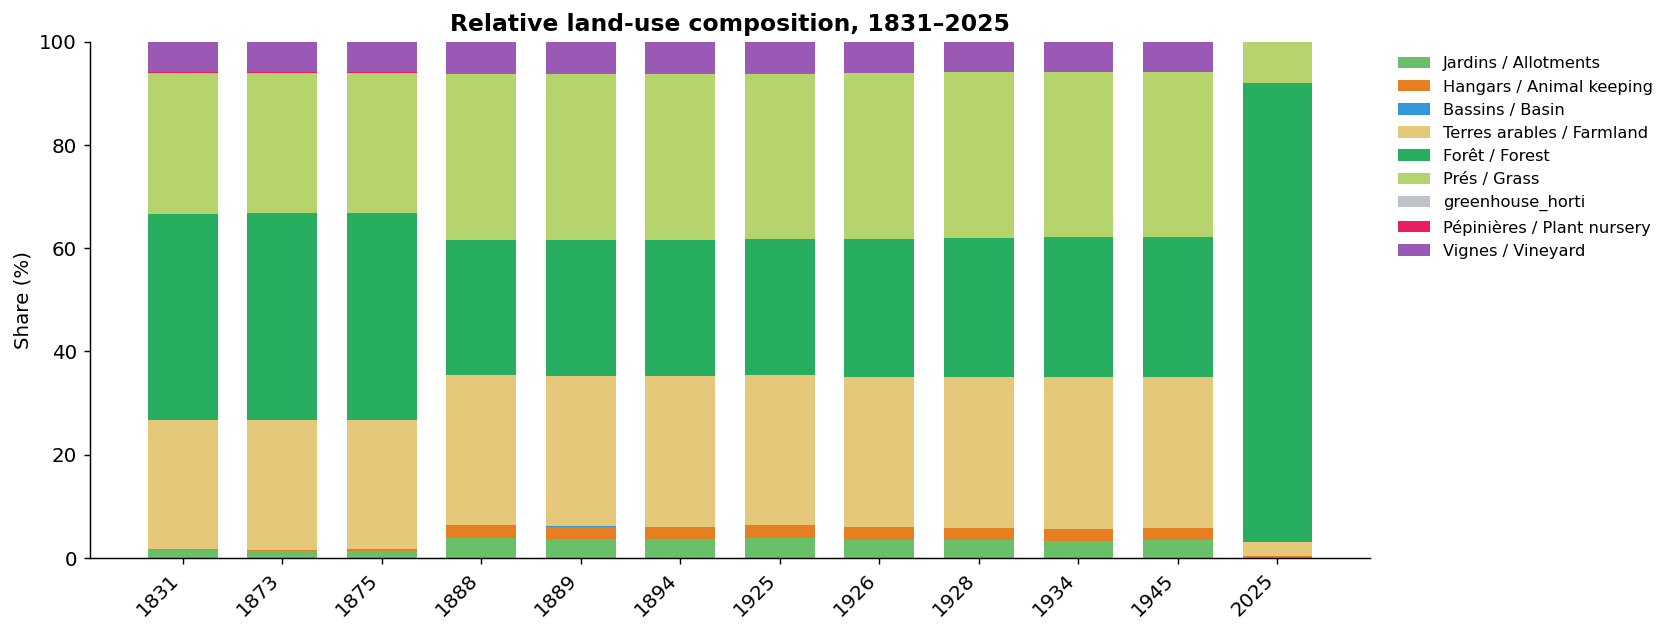

In [97]:
pct_pivot = area_pivot[cols].div(area_pivot[cols].sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(years))
for col, color, label in zip(cols, colors, labels):
    vals = pct_pivot[col].values
    ax.bar(range(len(years)), vals, bottom=bottom, color=color, label=label, width=0.7)
    bottom += vals

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, ha='right')
ax.set_ylabel('Share (%)')
ax.set_title('Relative land-use composition, 1831–2025', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_relative_composition.png', bbox_inches='tight')
plt.show()

## 8. Parcel count per use type over time

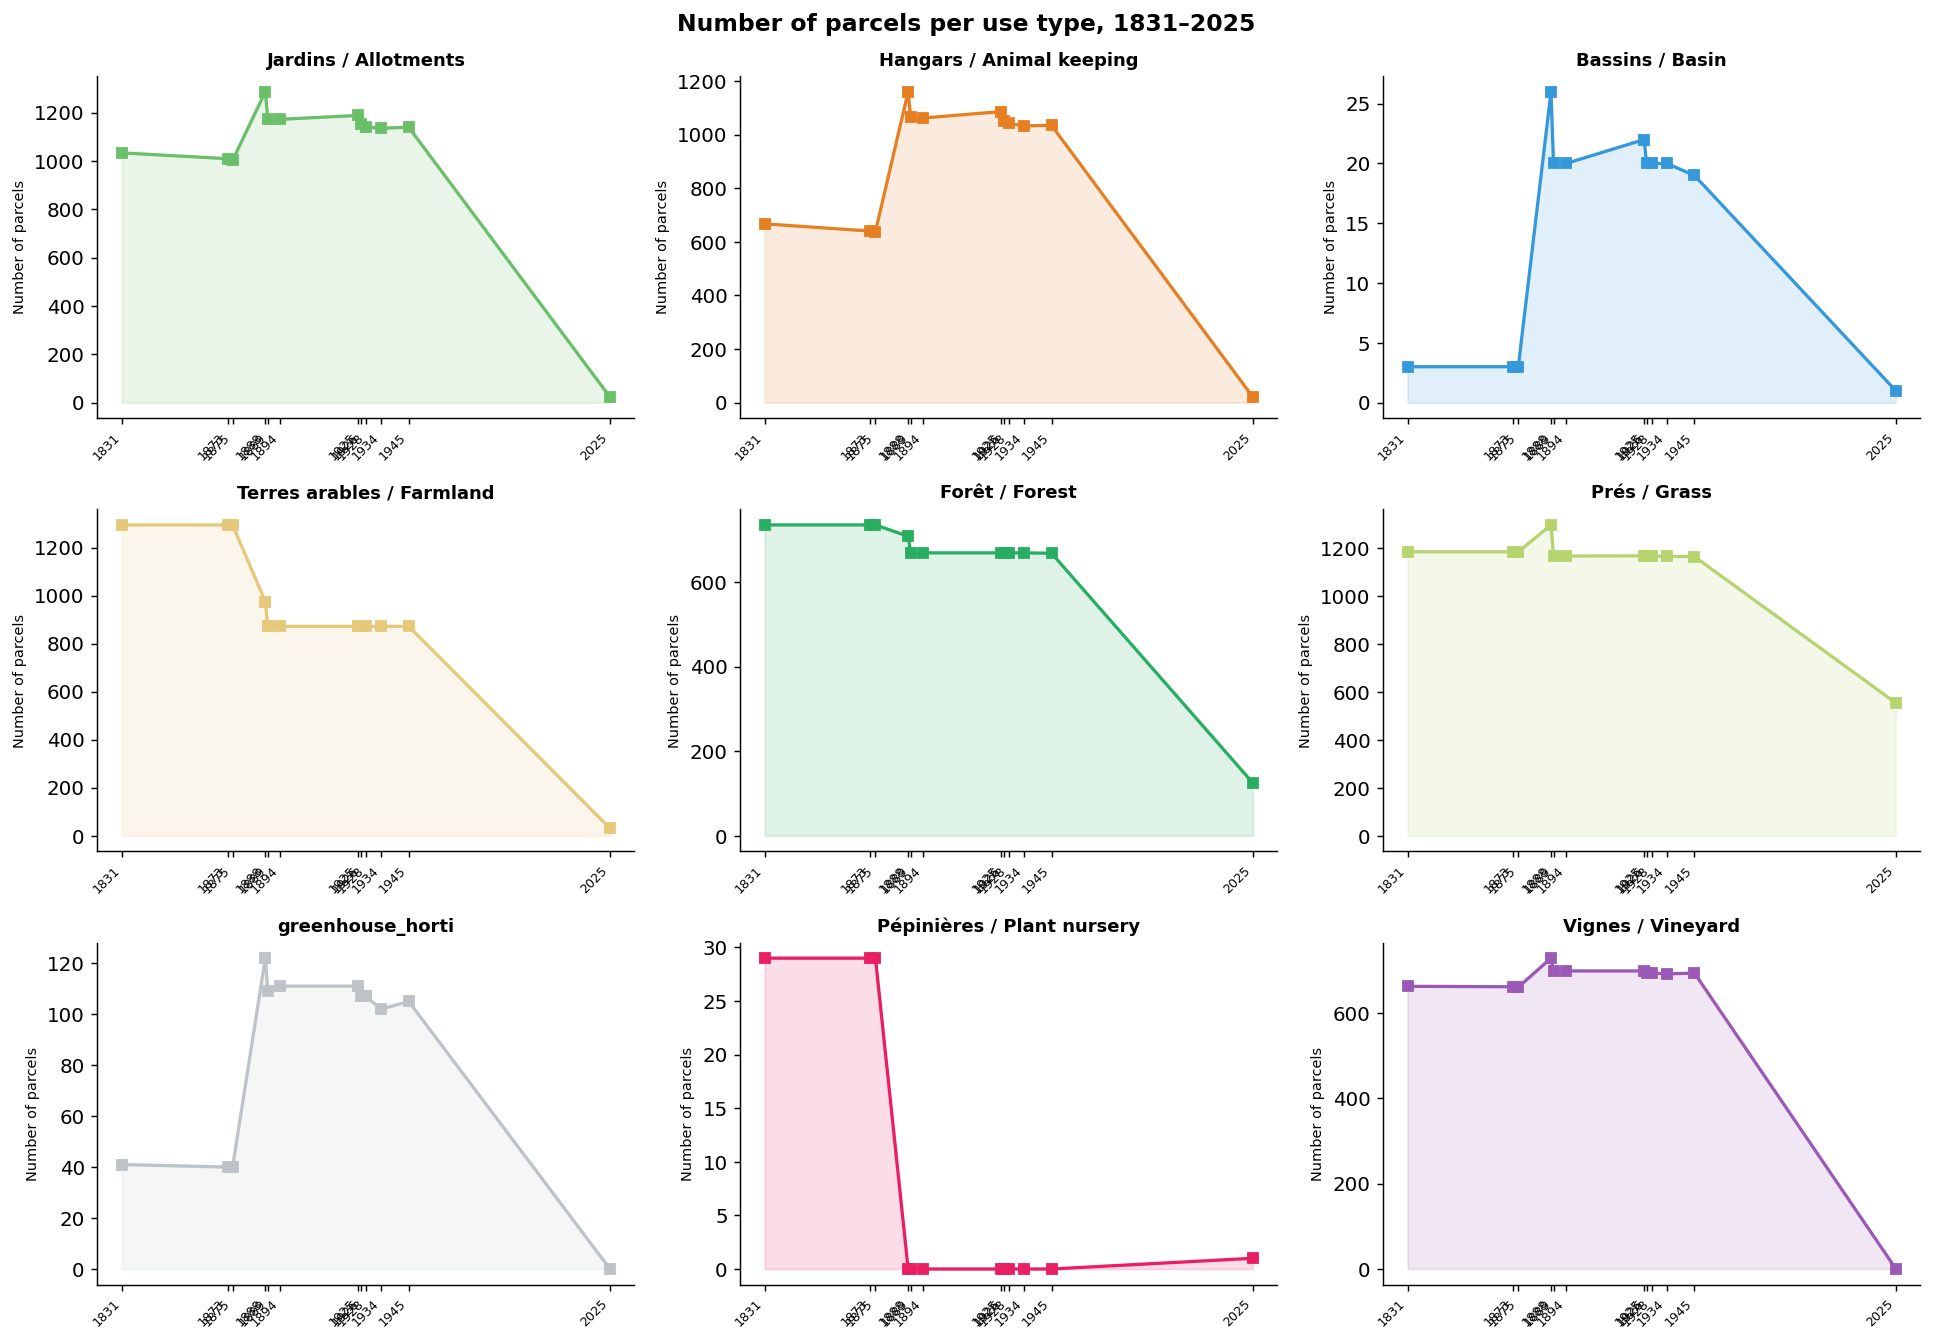

In [98]:
count_pivot = (
    all_gdf.groupby(['year', 'use_type'])['area_m2']
    .count()
    .unstack(fill_value=0)
    .sort_index()
)
count_cols = [c for c in count_pivot.columns if c in USE_COLORS]

ncols = 3
nrows = math.ceil(len(count_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, col in enumerate(count_cols):
    ax = axes[i]
    ax.plot(count_pivot.index, count_pivot[col], marker='s',
            color=USE_COLORS[col], linewidth=1.8, markersize=5)
    ax.set_title(USE_LABELS.get(col, col), fontweight='bold', fontsize=10)
    ax.set_xticks(count_pivot.index)
    ax.set_xticklabels(count_pivot.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Number of parcels', fontsize=8)
    ax.fill_between(count_pivot.index, count_pivot[col], alpha=0.15, color=USE_COLORS[col])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Number of parcels per use type, 1831–2025', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_parcel_count_by_use_type.png', bbox_inches='tight')
plt.show()

## 9. Average parcel size per use type over time

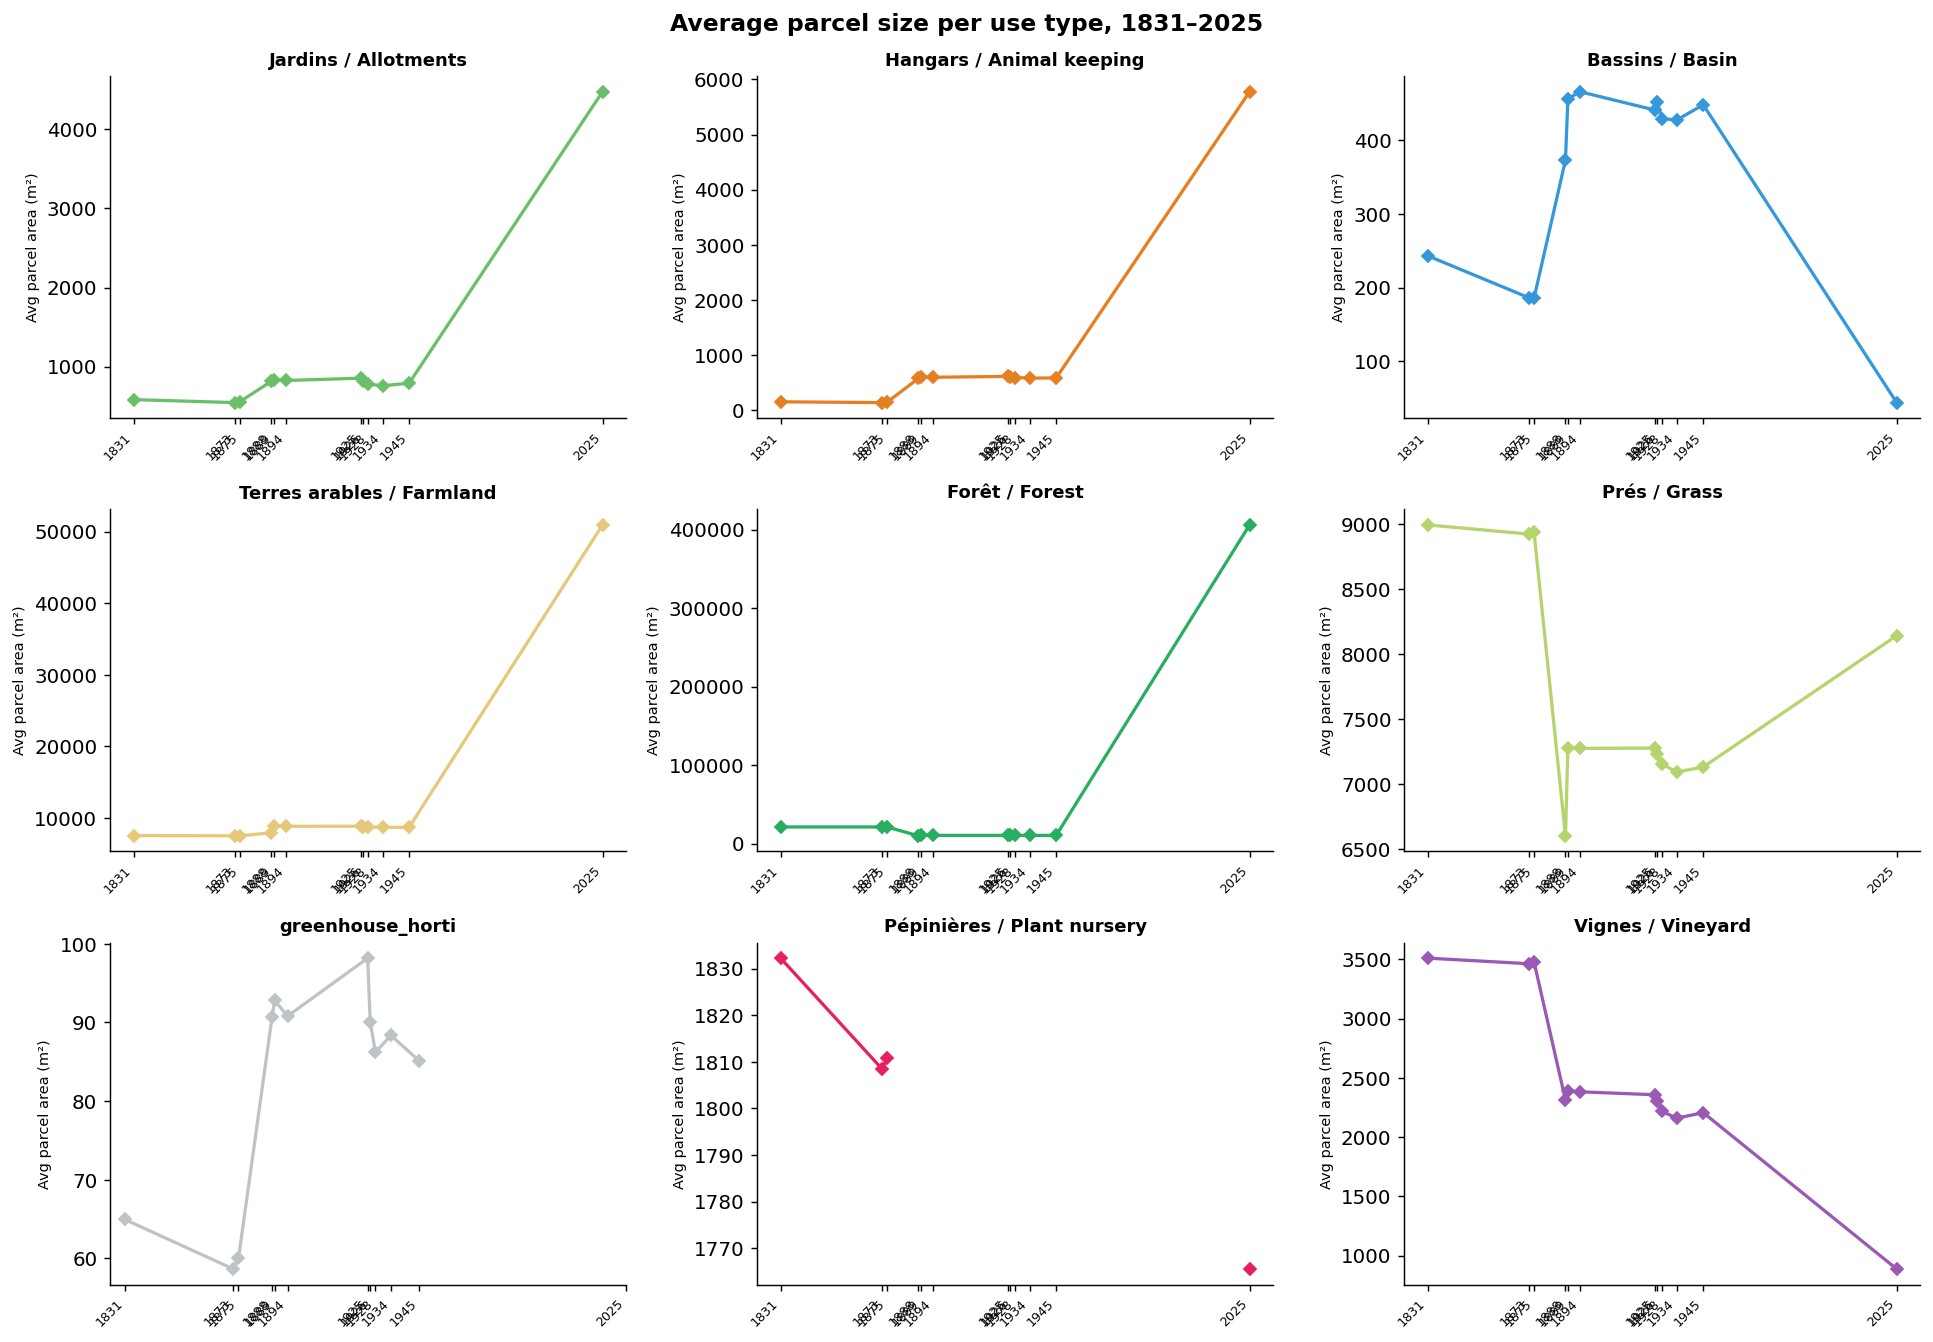

In [99]:
avg_size = (
    all_gdf.groupby(['year', 'use_type'])['area_m2']
    .mean()
    .unstack(fill_value=np.nan)
    .sort_index()
)
avg_cols = [c for c in avg_size.columns if c in USE_COLORS]

ncols = 3
nrows = math.ceil(len(avg_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, col in enumerate(avg_cols):
    ax = axes[i]
    ax.plot(avg_size.index, avg_size[col], marker='D',
            color=USE_COLORS[col], linewidth=1.8, markersize=5)
    ax.set_title(USE_LABELS.get(col, col), fontweight='bold', fontsize=10)
    ax.set_xticks(avg_size.index)
    ax.set_xticklabels(avg_size.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Avg parcel area (m²)', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Average parcel size per use type, 1831–2025', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_avg_parcel_size_by_use_type.png', bbox_inches='tight')
plt.show()

## 10. Pie charts — use composition at key years

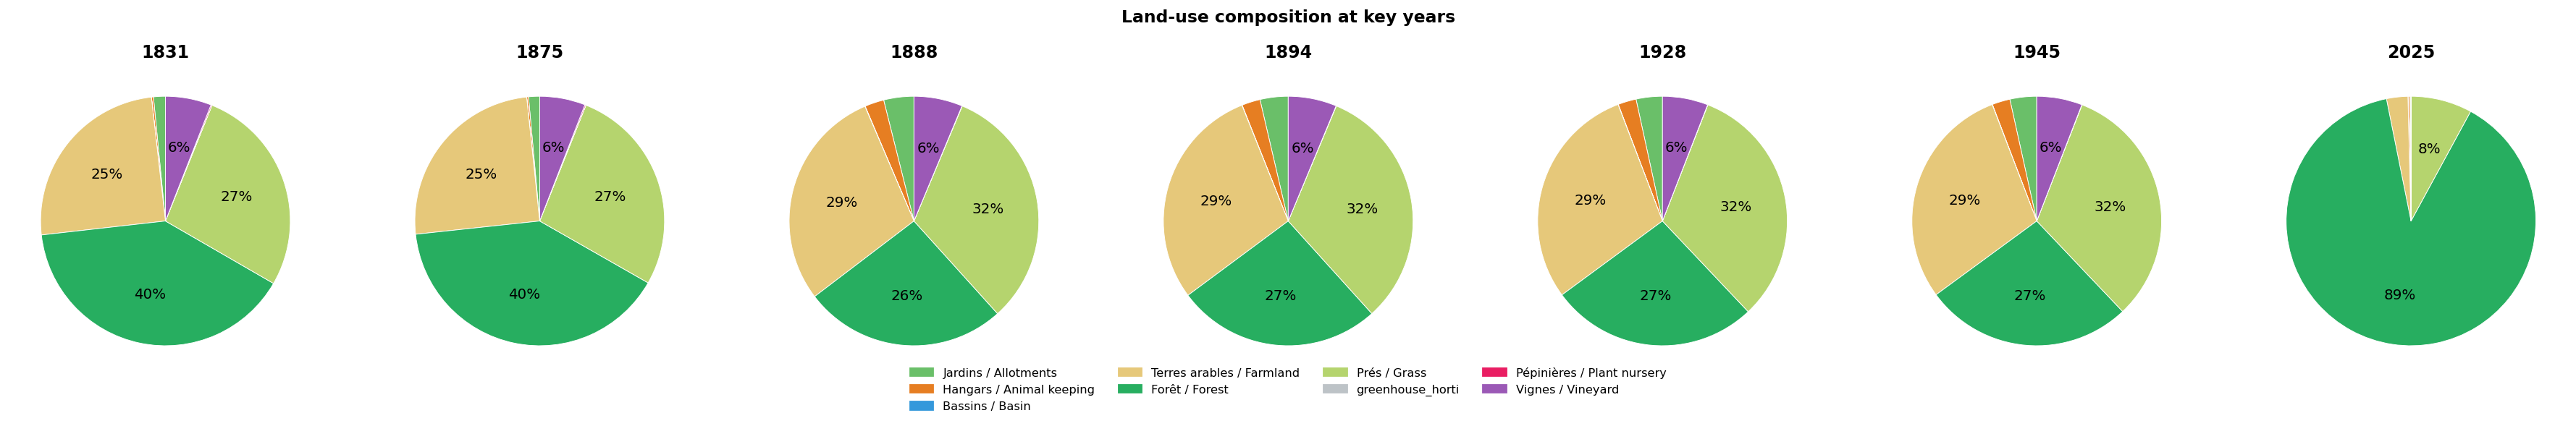

In [100]:
key_years = [1831, 1875, 1888, 1894, 1928, 1945, 2025]
key_years = [y for y in key_years if y in area_pivot.index]

fig, axes = plt.subplots(1, len(key_years), figsize=(4 * len(key_years), 4))
for ax, yr in zip(axes, key_years):
    row = area_pivot.loc[yr, cols]
    nonzero = row[row > 0]
    ax.pie(
        nonzero.values,
        colors=[USE_COLORS[c] for c in nonzero.index],
        autopct=lambda p: f'{p:.0f}%' if p > 4 else '',
        startangle=90,
        wedgeprops=dict(linewidth=0.5, edgecolor='white')
    )
    ax.set_title(str(yr), fontweight='bold')

patches = [mpatches.Patch(color=USE_COLORS[c], label=USE_LABELS.get(c, c)) for c in cols if c in USE_COLORS]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.suptitle('Land-use composition at key years', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_composition_pie_charts.png', bbox_inches='tight')
plt.show()

## 11. Net change in area — 1831 baseline vs. all other years

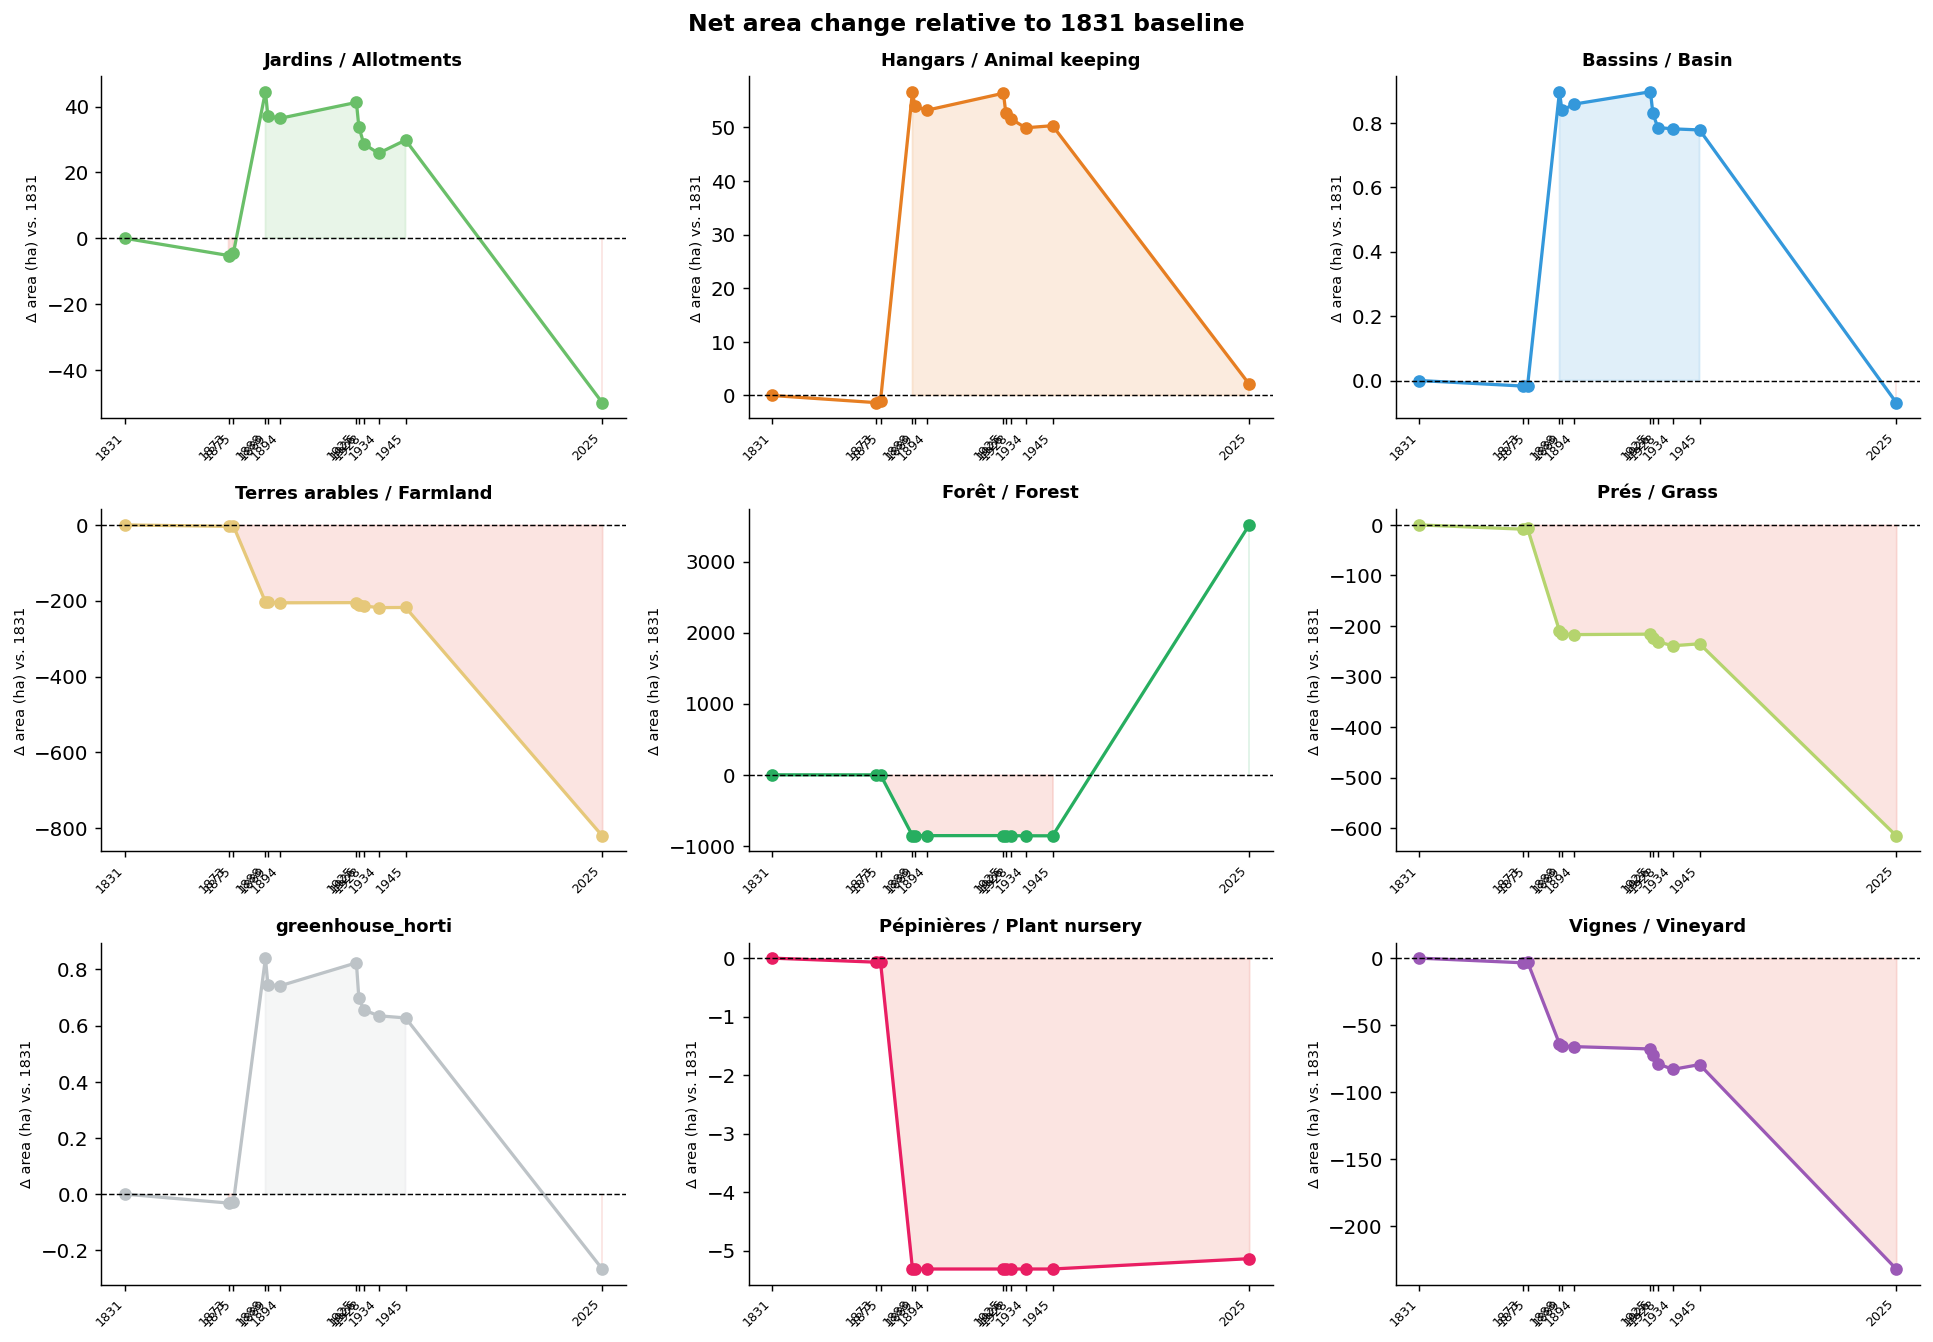

In [101]:
baseline = area_pivot.loc[1831, cols]
change = area_pivot[cols] - baseline

change_cols = [c for c in cols if change[c].abs().max() > 0]

ncols = 3
nrows = math.ceil(len(change_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, col in enumerate(change_cols):
    ax = axes[i]
    vals = change[col].values
    ax.plot(area_pivot.index, vals, marker='o', color=USE_COLORS[col], linewidth=1.8)
    ax.fill_between(area_pivot.index, vals, 0,
                    where=(vals >= 0), alpha=0.15, color=USE_COLORS[col])
    ax.fill_between(area_pivot.index, vals, 0,
                    where=(vals < 0),  alpha=0.15, color='#e74c3c')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(USE_LABELS.get(col, col), fontweight='bold', fontsize=10)
    ax.set_xticks(area_pivot.index)
    ax.set_xticklabels(area_pivot.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Δ area (ha) vs. 1831', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Net area change relative to 1831 baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '07_net_area_change.png', bbox_inches='tight')
plt.show()

## 12. Urbanisation pressure — area lost to buildings

' year  original_ha  approx_ha  lost_to_buildings_ha  pct_lost\n 1873      3913.25    3890.19                 23.06      0.59\n 1875      3913.25    3894.51                 18.74      0.48\n 1889      2678.66    2658.65                 20.01      0.75\n 1894      2678.66    2654.79                 23.87      0.89\n 1925      2678.66    2663.17                 15.49      0.58\n 1926      2678.66    2633.05                 45.61      1.70\n 1928      2678.66    2609.27                 69.39      2.59\n 1934      2678.66    2586.92                 91.74      3.42\n 1945      2678.66    2598.85                 79.81      2.98'

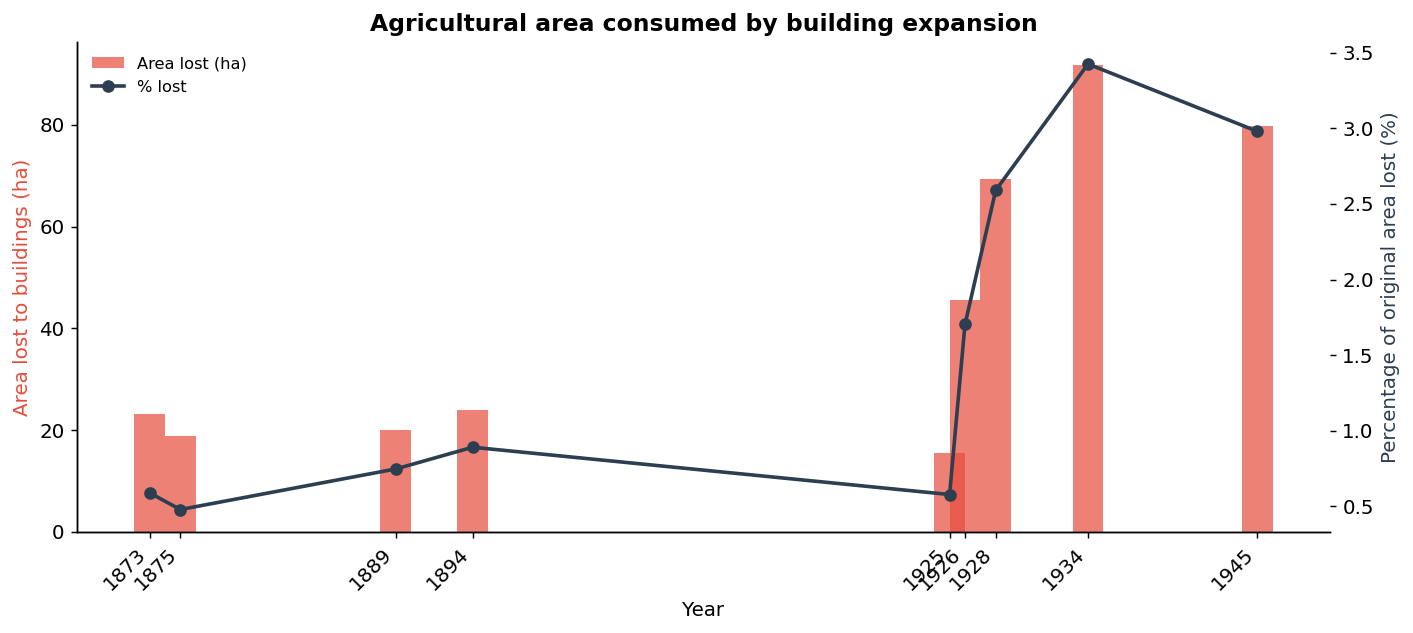

In [102]:
records = []
for yr, path in DIFFS.items():
    agr_yr = 1831 if yr < 1888 else 1888
    orig = all_gdf[(all_gdf['year'] == agr_yr) & (all_gdf['source'] == 'original')]['area_m2'].sum() / 1e4
    approx = all_gdf[(all_gdf['year'] == yr) & (all_gdf['source'] == 'approximation')]['area_m2'].sum() / 1e4
    records.append({'year': yr, 'original_ha': orig, 'approx_ha': approx,
                    'lost_to_buildings_ha': orig - approx,
                    'pct_lost': (orig - approx) / orig * 100})

urb_df = pd.DataFrame(records).sort_values('year')
display(urb_df.round(2).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(urb_df['year'], urb_df['lost_to_buildings_ha'], color='#e74c3c', alpha=0.7, width=2, label='Area lost (ha)')
ax2.plot(urb_df['year'], urb_df['pct_lost'], color='#2c3e50', marker='o', linewidth=2, label='% lost')

ax1.set_xlabel('Year')
ax1.set_ylabel('Area lost to buildings (ha)', color='#e74c3c')
ax2.set_ylabel('Percentage of original area lost (%)', color='#2c3e50')
ax1.set_title('Agricultural area consumed by building expansion', fontsize=13, fontweight='bold')
ax1.set_xticks(urb_df['year'])
ax1.set_xticklabels(urb_df['year'], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08_urbanisation_pressure.png', bbox_inches='tight')
plt.show()

## 13. Heatmap — area (ha) per use type × year

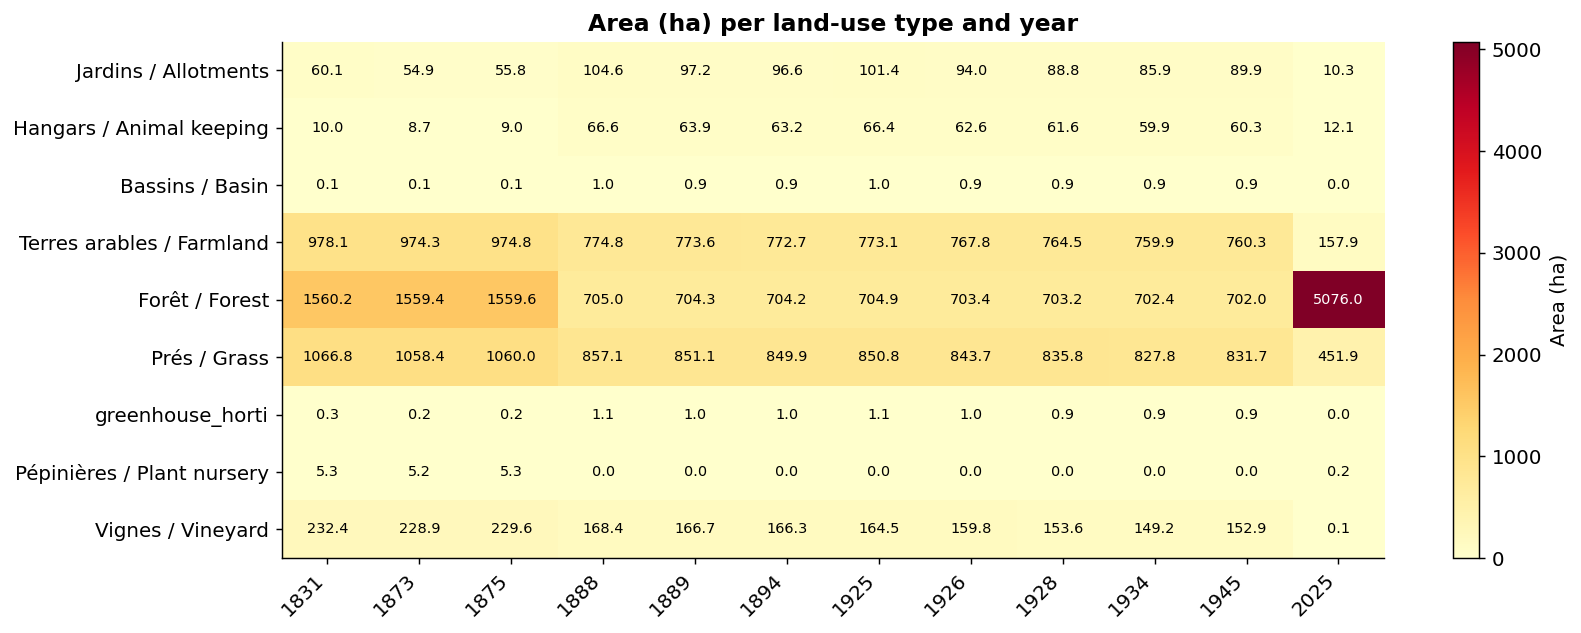

In [103]:
import matplotlib.colors as mcolors

hm_data = area_pivot[cols].T
hm_data.index = [USE_LABELS.get(c, c) for c in hm_data.index]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(hm_data.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_xticks(range(len(hm_data.columns)))
ax.set_xticklabels(hm_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(hm_data.index)))
ax.set_yticklabels(hm_data.index)

for i in range(hm_data.shape[0]):
    for j in range(hm_data.shape[1]):
        val = hm_data.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='black' if val < hm_data.values.max() * 0.6 else 'white')

plt.colorbar(im, ax=ax, label='Area (ha)')
ax.set_title('Area (ha) per land-use type and year', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '09_heatmap_area.png', bbox_inches='tight')
plt.show()

## 14. Top-10 largest parcels at each key year

In [104]:
for yr in [1831, 1888, 1945]:
    sub = all_gdf[all_gdf['year'] == yr][['use_type', 'use_fr', 'area_m2']].copy()
    sub = sub.nlargest(10, 'area_m2')
    sub['area_ha'] = (sub['area_m2'] / 1e4).round(4)
    print(f"\n── Top 10 largest parcels in {yr} ──")
    display(sub[['use_type', 'use_fr', 'area_ha']].reset_index(drop=True))


── Top 10 largest parcels in 1831 ──


,use_type,use_fr,area_ha
0,forest,bois,90.7180
1,forest,bois,69.4825
2,forest,bois,55.0526
3,forest,bois,51.0420
4,forest,bois,45.0997
5,forest,bois,43.6640
6,forest,bois,38.8927
7,forest,bois,37.4661
8,forest,bois,36.5957
9,forest,bois,35.1618



── Top 10 largest parcels in 1888 ──


,use_type,use_fr,area_ha
0,forest,Bois,60.5781
1,forest,Bois,43.9803
2,farmland,Champ,42.6252
3,forest,Bois,38.5797
4,forest,Bois,38.5645
5,forest,Bois,33.4055
6,forest,Bois,32.2300
7,animal_keeping,Etable à porcs,32.2300
8,farmland,Champ,24.9469
9,forest,Bois,19.2903



── Top 10 largest parcels in 1945 ──


,use_type,use_fr,area_ha
0,forest,Bois,60.5781
1,forest,Bois,43.9803
2,farmland,Champ,42.5909
3,forest,Bois,38.5797
4,forest,Bois,38.5645
5,forest,Bois,33.4055
6,forest,Bois,32.1706
7,animal_keeping,Etable à porcs,32.1706
8,farmland,Champ,24.9469
9,forest,Bois,19.2903


## 15. Key insights — numerical summary

In [105]:
def total_ha(year):
    return all_gdf[all_gdf['year'] == year]['area_m2'].sum() / 1e4

def ha_by_use(year, use):
    return all_gdf[(all_gdf['year'] == year) & (all_gdf['use_type'] == use)]['area_m2'].sum() / 1e4

print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

t1831 = total_ha(1831)
t1888 = total_ha(1888)
t1945 = total_ha(1945)
print(f"\n[1] Total agricultural footprint")
print(f"    1831 : {t1831:.2f} ha")
print(f"    1888 : {t1888:.2f} ha  (Δ {t1888-t1831:+.2f} ha vs 1831)")
print(f"    1945 : {t1945:.2f} ha  (Δ {t1945-t1888:+.2f} ha vs 1888)")

print(f"\n[2] Urbanisation (area consumed by buildings vs. original)")
for r in records:
    print(f"    {r['year']}: −{r['lost_to_buildings_ha']:.2f} ha ({r['pct_lost']:.1f}% of original agr cadastre)")

print(f"\n[3] Vineyard evolution")
for yr in sorted(all_gdf['year'].unique()):
    h = ha_by_use(yr, 'vineyard')
    print(f"    {yr}: {h:.2f} ha")

print(f"\n[4] Garden/allotments evolution")
for yr in sorted(all_gdf['year'].unique()):
    h = ha_by_use(yr, 'allotments')
    print(f"    {yr}: {h:.2f} ha")

print(f"\n[5] Grassland (prés) evolution")
for yr in sorted(all_gdf['year'].unique()):
    h = ha_by_use(yr, 'grass')
    print(f"    {yr}: {h:.2f} ha")

print(f"\n[6] Median parcel size per year")
for yr in sorted(all_gdf['year'].unique()):
    med = all_gdf[all_gdf['year'] == yr]['area_m2'].median()
    print(f"    {yr}: {med:.1f} m²")

print("\n" + "=" * 60)

KEY INSIGHTS

[1] Total agricultural footprint
    1831 : 3913.25 ha
    1888 : 2678.66 ha  (Δ -1234.59 ha vs 1831)
    1945 : 2598.85 ha  (Δ -79.81 ha vs 1888)

[2] Urbanisation (area consumed by buildings vs. original)
    1873: −23.06 ha (0.6% of original agr cadastre)
    1875: −18.74 ha (0.5% of original agr cadastre)
    1889: −20.01 ha (0.7% of original agr cadastre)
    1894: −23.87 ha (0.9% of original agr cadastre)
    1925: −15.49 ha (0.6% of original agr cadastre)
    1926: −45.61 ha (1.7% of original agr cadastre)
    1928: −69.39 ha (2.6% of original agr cadastre)
    1934: −91.74 ha (3.4% of original agr cadastre)
    1945: −79.81 ha (3.0% of original agr cadastre)

[3] Vineyard evolution
    1831: 232.41 ha
    1873: 228.92 ha
    1875: 229.63 ha
    1888: 168.36 ha
    1889: 166.66 ha
    1894: 166.28 ha
    1925: 164.53 ha
    1926: 159.76 ha
    1928: 153.61 ha
    1934: 149.23 ha
    1945: 152.87 ha
    2025: 0.09 ha

[4] Garden/allotments evolution
    1831: 60.13 